In [1]:
import jax 
import jax.numpy as jnp
import haiku as hk
import optax

from probjax.nn.transformers import Transformer
from probjax.nn.tokenizer import scalarize, ScalarTokenizer
from probjax.nn.helpers import GaussianFourierEmbedding, SinusoidalEmbedding
from probjax.nn.loss_fn import denoising_score_matching_loss

import matplotlib.pyplot as plt

from functools import partial

In [13]:
dimension = 2
def gaussian_simulator(key, n):
    theta = jax.random.normal(key, (n, dimension))
    x = theta +  1e-1 * jax.random.normal(key, theta.shape) + 10.
    return jnp.concatenate([theta,x], axis=-1)

data = gaussian_simulator(jax.random.PRNGKey(0), 100000).reshape(-1,2*dimension,1)
num_nodes = data.shape[-2]
node_id = jnp.arange(num_nodes)

# Test

In [3]:

def model(t,data, data_id):
    dim = 40
    tokenizer = ScalarTokenizer(dim, len(node_id))
    time_embeder = SinusoidalEmbedding(256)
    
    # Embedding
    tokens = tokenizer(data_id,data)
    time = time_embeder(t[..., None])
    

    model = Transformer(num_heads=1, num_layers=4, attn_size=dim, widening_factor=5)
    h = model(tokens, context=time)
    out = hk.Linear(1)(h)
    return out

init_fn, model_fn = hk.without_apply_rng(hk.transform(model))
params = init_fn(jax.random.PRNGKey(0), jnp.zeros(data[:10].shape[0],),data[:10], node_id)
out = model_fn(params, jnp.zeros(data[:10].shape[0],),data[:10], node_id)


In [4]:
from probjax.distributions.sde import VPSDE, BaseSDE
from probjax.distributions import Normal, Independent
from probjax.distributions.discrete import Empirical

In [5]:
p0 = Independent(Empirical(data), 2)
beta_max = 20.
sde = VPSDE(p0, beta_max=beta_max)
t = jnp.linspace(0,1,200)

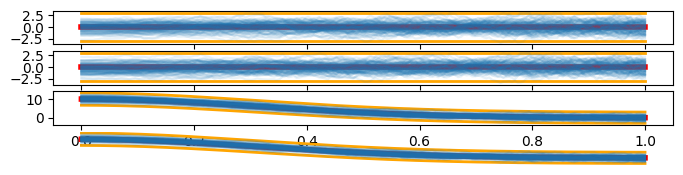

In [6]:
mean = sde.mean(t)
std = sde.stddev(t)
forward_samples = sde.sample(jax.random.PRNGKey(0), t, sample_shape=(100,))

fig, axes = plt.subplots(2*dimension,1, figsize=(8, dimension))
for i in range(len(axes)):
    _ = axes[i].plot(t, mean[:,i,0].T, lw=4, color="red")
    _ = axes[i].plot(t, mean[:,i,0].T + 3*std[:,i,0].T, lw=2, color="orange")
    _ = axes[i].plot(t, mean[:,i,0].T - 3*std[:,i,0].T, lw=2, color="orange")
    _ = axes[i].plot(t, forward_samples[...,i,0].T, color="C0", alpha=0.1)

_ = plt.axis("off")

In [7]:
# VPSDE 
T = 1.
T_min = 1e-6
beta_min = 0.1

def weight_fn(t):
    t = t.reshape(-1,1,1)
    return 1-jnp.exp(-0.5 * (beta_max - beta_min) * t**2 - beta_min * t) + 1e-3

In [8]:
optimizer = optax.adam(1e-4)
opt_state = optimizer.init(params)

In [9]:
def loss_fn(params, key, data, node_id, mask = None):
    key_times, key_loss = jax.random.split(key)
    times = jax.random.uniform(key_times, (data.shape[0],), minval=T_min, maxval =1.)
    loss = denoising_score_matching_loss(params, key_loss, times, data, mask, node_id, model_fn = model_fn, mean_fn = sde.marginal_mean, std_fn=sde.marginal_stddev, weight_fn=weight_fn)
    return loss



@partial(jax.pmap, axis_name="num_devices")
def update(params, opt_state, key, data, node_id):
    loss, grads = jax.value_and_grad(loss_fn)(params, key, data, node_id)

    loss = jax.lax.pmean(loss, axis_name="num_devices")
    grads = jax.lax.pmean(grads, axis_name="num_devices")
    
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state
    

In [10]:
num_epochs = 200
batch_size = 1000
num_devices = jax.device_count()
batch_size_per_device = batch_size // num_devices
num_steps = data.shape[0] // batch_size_per_device + 1

In [11]:
replicated_params = jax.tree_map(lambda x: jnp.array([x] * num_devices), params)
replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * num_devices), opt_state)

In [12]:

key = jax.random.PRNGKey(1)
for j in range(num_epochs):
    l = 0
    for i in range(num_steps):
        key_batch, key_update = jax.random.split(key)
        data_batch = jax.random.choice(key_batch,data, shape=(num_devices, batch_size_per_device, ), axis=0)
        loss, replicated_params, replicated_opt_state = update(replicated_params, replicated_opt_state, jax.random.split(key_update, (num_devices,)), data_batch, node_id[None,...])
        l += loss[0] /num_steps
    if (j % 10) == 0:     
        print(l)

(1000, 4, 1) (1000, 4, 1)
(1000, 1, 1)
3.5940397
1.8509563


KeyboardInterrupt: 

In [30]:
params = jax.tree_map(lambda x: x[0], replicated_params)

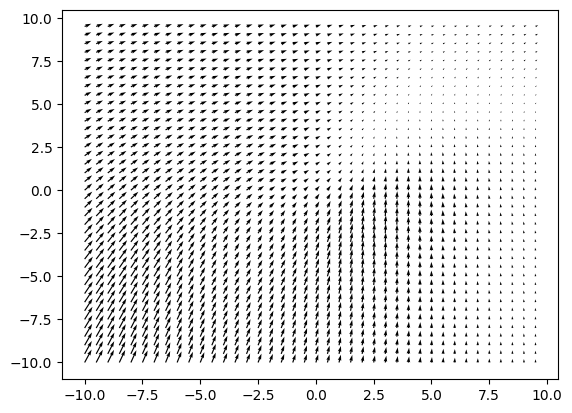

In [31]:
%matplotlib inline
# Check vector field
x, y = jnp.meshgrid(jnp.arange(-10, 10, 0.5), jnp.arange(-10, 10, 0.5))
pos = jnp.dstack((x, y)).reshape(-1, 2, 1)
vs = model_fn(params, jnp.ones((pos.shape[0],)) * 1., pos, jnp.array([0,1]))

plt.quiver(pos[:, 0], pos[:, 1], vs[:, 0], vs[:, 1])

In [32]:

def score_fn(t, x):
    score = model_fn(params, jnp.atleast_1d(t), x, node_id)
    return score

def drift_backwards(t, x):
    t = (1- t)
    score = score_fn(t, x)
    drift = sde.drift(t, x) - sde.diffusion(t, x)**2 * score 
    return -drift

def diffusion_backwards(t, x):
    t = (1-t)
    diffusion = sde.diffusion(t, x) 
    return diffusion

t = jnp.linspace(0,1-T_min,200)
p_T = Independent(Normal(sde.marginal_mean(jnp.ones(1)), sde.marginal_stddev(jnp.ones(1))), 2)
target_sde = BaseSDE(drift_backwards, diffusion_backwards, p_T)

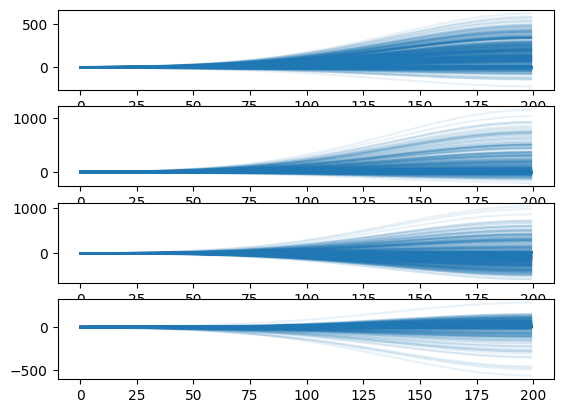

In [33]:

forward_samples = target_sde.sample(jax.random.PRNGKey(0), t, sample_shape=(1000,))

fig, axes = plt.subplots(2*dimension,1)
for i in range(len(axes)):
    _ = axes[i].plot(forward_samples[...,i,0].T, color="C0", alpha=0.1)
